## Ex1 -- Advanced Exercise 3
_Using `CatBoostRegressor`_

<br>
<br>




### Dataset: [College Placements](https://www.kaggle.com/datasets/sutariyasmit01/local-college-placements-dataset)

|Parameter|Description|
|---|---|
|Shape|_`1050 rows, 11 columns`_|
|Target Variable|_`CGPA`_|
|Model:|_`CatBoostRegressor`_|
|Extra Tools:|_`mlflow`_|
|Columns Descriptions|`__`|

#### Summary:

<i>
Add Text Here.
</i>

#### Results:

<i>
Add Text Here.
</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import datetime as dt
import mlflow
import warnings
warnings.filterwarnings('ignore') 

# Loading the datasets
df = pd.read_csv("datasets/college_placements.csv")
df.head(5)

,Student_ID,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,Placement_Status
0,STU0001,Male,IT,7.66,2,0,Beginner,97.6,Average,0,Placed
1,STU0002,Female,IT,8.44,1,2,Advanced,75.5,Average,3,Placed
2,STU0003,Female,ECE,7.16,1,2,Beginner,76.8,Average,1,Not Placed
3,STU0004,Male,ME,6.14,1,1,Intermediate,55.4,Good,3,Placed
4,STU0005,Male,ME,6.82,2,0,Advanced,65.9,Poor,2,Placed


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

##### Checking the shape (Rows, Columns)

In [22]:
# Let's first look at the shape
df.shape

# 1050 rows, seems fine!

(1050, 11)

#### Handling Duplicates

In [23]:
# Let's look at the amount of duplicates we have.
df.duplicated().value_counts()

# None, perfect.

False    1050
Name: count, dtype: int64

#### Handling Missing Values

In [24]:
# Let's now check the amount of NaN values.
df.isna().sum()

# None as well! Lucky.

Student_ID              0
Gender                  0
Branch                  0
CGPA                    0
Internships             0
Backlogs                0
Programming_Skills      0
Aptitude_Score          0
Communication_Skills    0
Extra_Certifications    0
Placement_Status        0
dtype: int64

In [25]:
df

,Student_ID,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,Placement_Status
0,STU0001,Male,IT,7.66,2,0,Beginner,97.6,Average,0,Placed
1,STU0002,Female,IT,8.44,1,2,Advanced,75.5,Average,3,Placed
2,STU0003,Female,ECE,7.16,1,2,Beginner,76.8,Average,1,Not Placed
3,STU0004,Male,ME,6.14,1,1,Intermediate,55.4,Good,3,Placed
4,STU0005,Male,ME,6.82,2,0,Advanced,65.9,Poor,2,Placed
...,...,...,...,...,...,...,...,...,...,...,...
1045,STU1046,Female,CE,7.80,0,1,Advanced,58.0,Good,5,Placed
1046,STU1047,Male,IT,4.64,3,4,Intermediate,57.1,Good,1,Not Placed
1047,STU1048,Male,ME,5.94,2,3,Beginner,50.6,Good,5,Not Placed
1048,STU1049,Female,IT,4.68,1,1,Advanced,76.2,Good,5,Placed


#### Dropping Columns

In [26]:
# Dropping any columns which aren't related to the modeling.
df = df.drop(["Student_ID"], axis=1)            # This column is only for identification.


#### Categorical Features Isolated Case Elimination

Any categorical features we create might sometimes create too many cases.

That's a problem because each of these categories will be a bucket, which takes it's own weight value. I like to describe this situation like _putting a five-hundred euro bet by asking ONE person on the side of the road which team would win the Superbowl._ Naturally, that's not very statistical. So, let's look at all of these categorical variables more closely.

`Gender`

In [27]:
df["Gender"].value_counts()

Gender
Male      638
Female    412
Name: count, dtype: int64

`Branch`

In [28]:
df['Branch'].value_counts()

Branch
IT     227
CE     221
ECE    215
CSE    204
ME     183
Name: count, dtype: int64

`Programming_Skills`

In [29]:
df['Programming_Skills'].value_counts()

Programming_Skills
Intermediate    495
Beginner        346
Advanced        209
Name: count, dtype: int64

`Communication_Skills`

In [30]:
df["Communication_Skills"].value_counts()

Communication_Skills
Average    511
Good       329
Poor       210
Name: count, dtype: int64

`Placement_Status`

In [31]:
df["Placement_Status"].value_counts()

Placement_Status
Placed        538
Not Placed    512
Name: count, dtype: int64

<b>Results:</b>

Each of these columns seem OK! They all an adequate amount of samples to represent a statistic.

#### Turning Columns Into Numbers

No need, I believe! Since we're using `CatBoostRegressor`

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Training & Metrics|

####  Target Variable Distribution Check

The target variable here is `CGPA`, so let's analyse the distribution a bit more closely.

<Axes: xlabel='CGPA', ylabel='Count'>

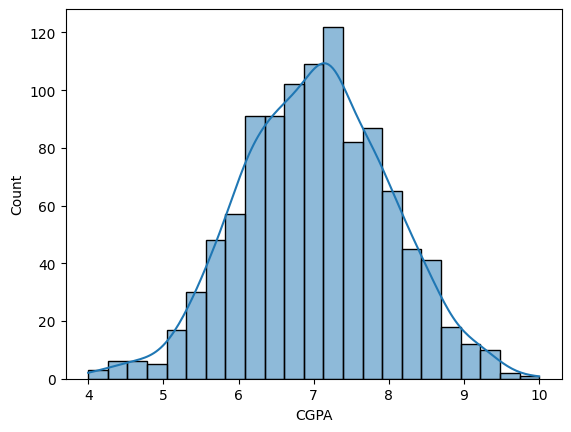

In [53]:
# Creating a scatterplot of the dependent variable.
sns.histplot(df, x="CGPA", kde=True)

# Well then. Perfect!

#### Feature selection

Since we have such a few amount of columns, I don't think we would need to drop columns. But just to be sure, let's look for multi-colinearity

<Axes: >

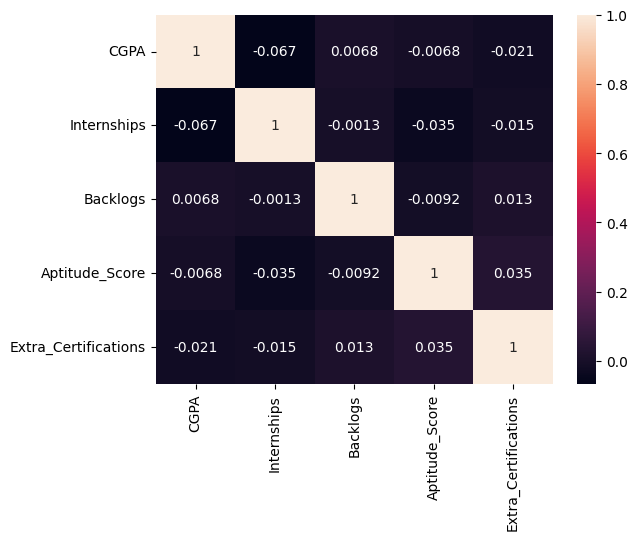

In [51]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)


These correlations are ASTRONOMICALLY low. I'm suspicious that this is synthetic data with no rhyme or reason.

Let's investigate and look at some more distributions.

#### Investigating The Other Column Distributions

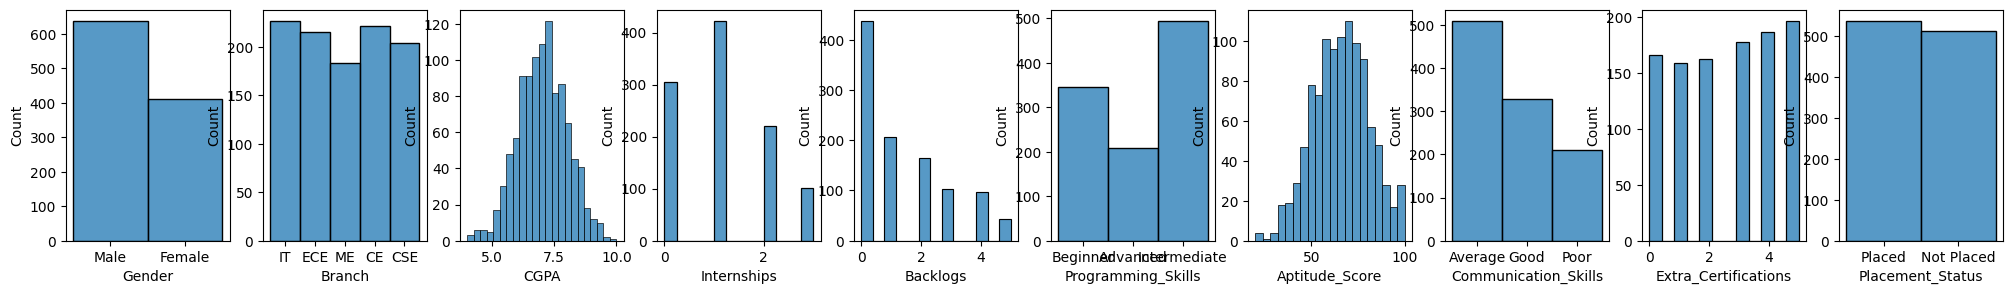

In [50]:
# Create a canvas as many plots as there are columns.
fig, axes = plt.subplots(1,len(df.columns), figsize=(25,3))

# For each column, create a histplot.
for index, column in enumerate(list(df.columns)):
    sns.histplot(df, x=column, ax = axes[index])

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Observations</h3>

I'm not convinced that this is actually a real dataset. These distributions are incredibly suspicious and I have a feeling we're going to get terrible results.

But with that in mind, it's likely ok -- Since we're just testing `CatBoostRegressor`, we'll let it slide. No need to get a good result.

</div>

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|

In [57]:
df

,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,Placement_Status
0,Male,IT,7.66,2,0,Beginner,97.6,Average,0,Placed
1,Female,IT,8.44,1,2,Advanced,75.5,Average,3,Placed
2,Female,ECE,7.16,1,2,Beginner,76.8,Average,1,Not Placed
3,Male,ME,6.14,1,1,Intermediate,55.4,Good,3,Placed
4,Male,ME,6.82,2,0,Advanced,65.9,Poor,2,Placed
...,...,...,...,...,...,...,...,...,...,...
1045,Female,CE,7.80,0,1,Advanced,58.0,Good,5,Placed
1046,Male,IT,4.64,3,4,Intermediate,57.1,Good,1,Not Placed
1047,Male,ME,5.94,2,3,Beginner,50.6,Good,5,Not Placed
1048,Female,IT,4.68,1,1,Advanced,76.2,Good,5,Placed


In [59]:
# Defining the dependent and independent variables
X = df.drop("CGPA", axis=1)
y = df["CGPA"]

cat_features = ["Gender", "Branch", "Programming_Skills", "Communication_Skills", "Placement_Status"]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Initializing `CatBoostRegressor` model.
# cb = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.1,
#     depth=6,
#     verbose=0
# )

# cb.fit(X_train, y_train, cat_features=cat_features)

rf = RandomForestRegressor(max_depth=2, random_state=0)

# Predicting the test features.
predictions = cb.predict(X_test)

# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

METRICS
--------------------------
MAE
0.72 

MSE
0.86 

RMSE
0.93 

R-squared:
0.11 



---




<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

### Personal Analysis

The results were actually not bad, considering the lack of correlation values. CGPA is an Indian GPA, essentially (0-10), so that means the average each prediction is off is 7%. Quite impressive, considering the strange dataset.

What I want to know is whether or not the results were due to a superior model or a superior dataset! 

That really makes me want to dig a little deeper in how this model works. I will write a paragraph about the results of that research below.


### Post Research

Catboost (Categorical Boost) uses a special type of gradient descent method (just like typical neural networks) called gradient-boosting. `CatBoostRegressor` is an ensemble model, meaning that it uses multiple ML models at once.


<b> How it works:</b>
You can give `CatBoostRegressor` a parameter of iterations, which serves kind of as the 'steps' for gradient descent. But, instead of using steps -- It uses a decision-tree method, where after each iteration, it will take the residiual amount error and create another decision-tree to fix that residual amount of error. 

Basically, gradient-descent... Tree Edition.

<b>Sources:</b>
|Description|Link|
|---|---|
|How Catboost works|[Source](https://www.geeksforgeeks.org/machine-learning/regression-using-catboost/)
|How `CatBoostRegressor` works|[Source](https://builtin.com/machine-learning/catboost)

</div>